กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/01?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 101.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 102.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 103.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 104.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 105.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']



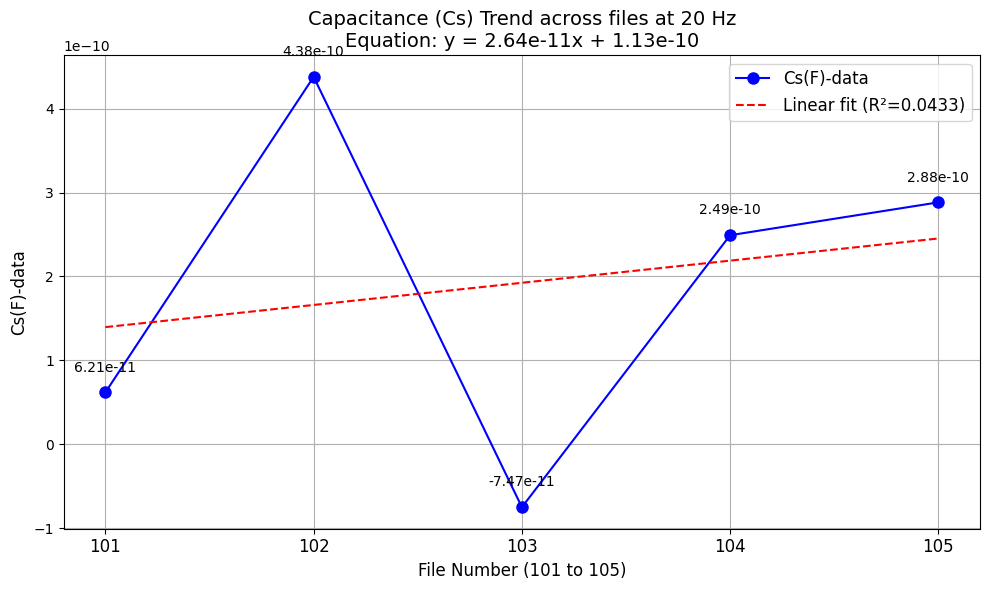

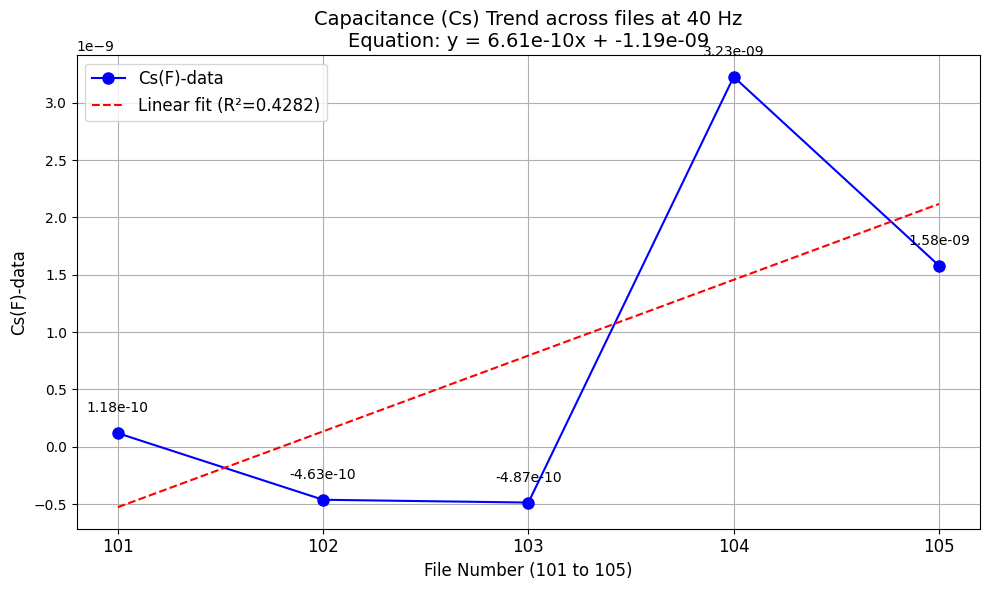

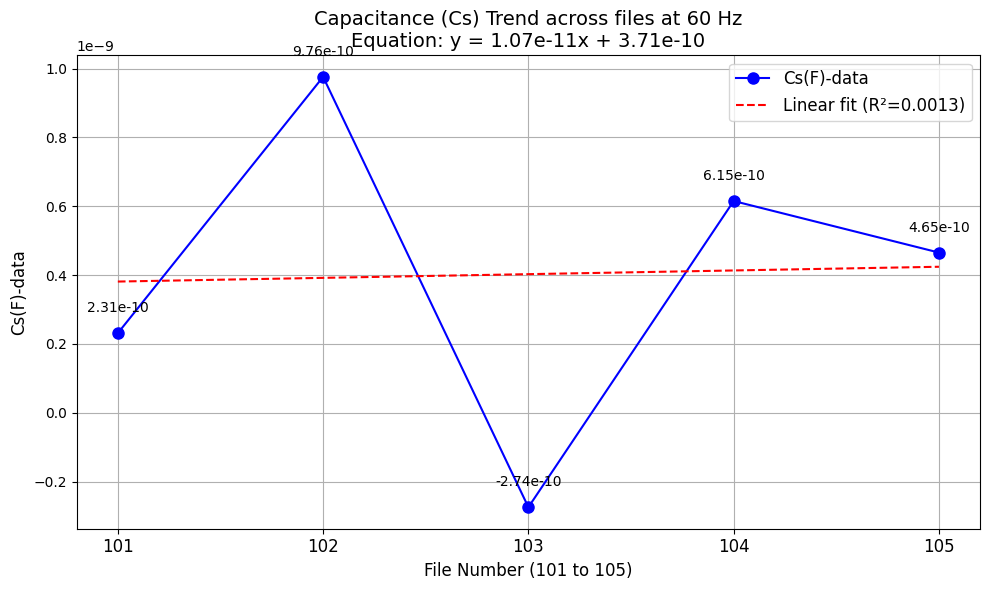

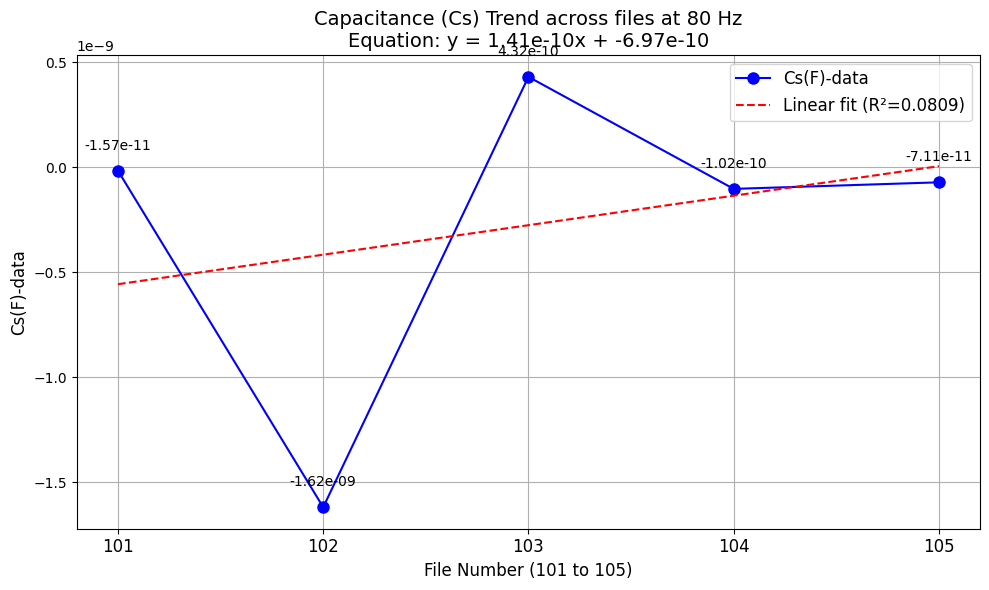

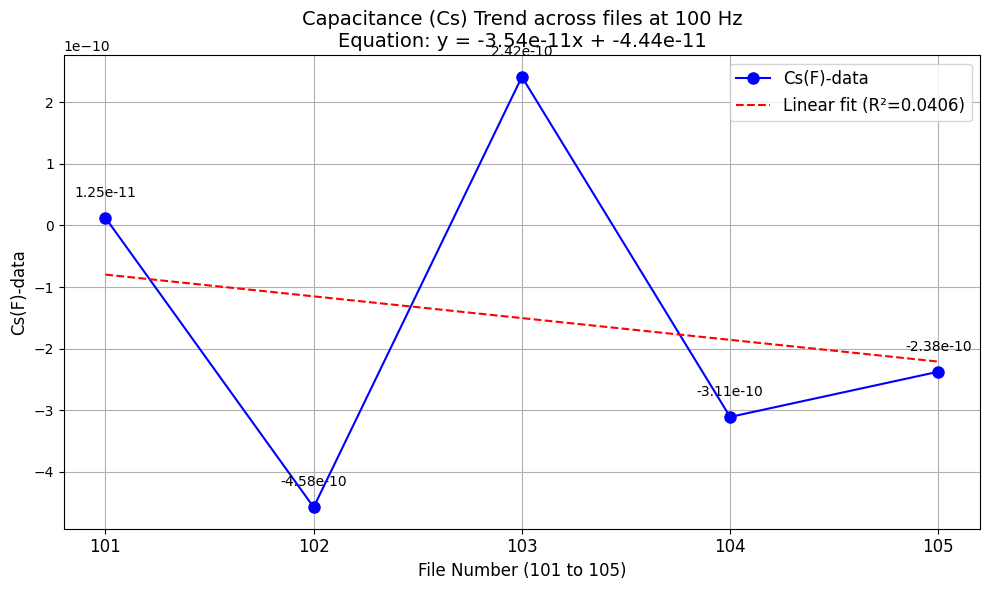

In [6]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from io import StringIO

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # สนใจเฉพาะไฟล์ 101-105
    target_files = ['101.csv', '102.csv', '103.csv', '104.csv', '105.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ดึง Text มาลบ Header 
            raw_text = session.get(url, headers=headers).text
            lines = raw_text.split('\n')
            
            start_idx = 0
            for i, line in enumerate(lines):
                if line.startswith('Frequency'):
                    start_idx = i
                    break
                    
            csv_data = StringIO('\n'.join(lines[start_idx:]))
            df = pd.read_csv(csv_data)
            df.columns = [c.strip() for c in df.columns]
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # เก็บไฟล์ด้วย Key ที่เป็นตัวพิมพ์ใหญ่เพื่อความชัวร์ ('101.CSV', '102.CSV', ...)
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. ดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN") 
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset/01"

# โหลดข้อมูลมาไว้ในตัวแปร dataframes
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. วาดกราฟ 1 กราฟ ต่อ 1 ความถี่ (รวมข้อมูลจากทุกไฟล์)
# ==========================================
frequencies = [20.0, 40.0, 60.0, 80.0, 100.0]
target_files = ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']
file_labels = ['101', '102', '103', '104', '105']

# แกน X ใช้ตัวเลข 1, 2, 3, 4, 5 เพื่อให้คำนวณ Linear Regression ได้
x = np.arange(1, 6) 

# วนลูปวาดกราฟตามความถี่ (จะได้ 5 กราฟ)
for freq in frequencies:
    cs_vals = []
    
    # ดึงค่า Cs จากไฟล์ 101 ถึง 105 ที่ความถี่เดียวกัน
    for f_name in target_files:
        if f_name in dataframes:
            df = dataframes[f_name]
            row = df[np.isclose(df['Frequency(Hz)'], freq)]
            if not row.empty:
                cs_vals.append(row['Cs(F)-data'].values[0])
            else:
                cs_vals.append(np.nan)
        else:
            cs_vals.append(np.nan)
            
    y = np.array(cs_vals)
    valid_idx = ~np.isnan(y) # เช็คว่าจุดไหนไม่มีค่า (NaN)
    
    plt.figure(figsize=(10, 6))
    
    # พล็อตจุดเชื่อมแต่ละไฟล์
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # หาค่าเทรนด์ (Linear Regression)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz\nEquation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend across files at {int(freq)} Hz'
        
    # ใส่ตัวเลขค่า Cs กํากับบนจุดแต่ละจุด
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # จัดการ Label 
    plt.title(title_text, fontsize=14)
    plt.xticks(x, file_labels, fontsize=12) # เปลี่ยนเลขแกน X ให้เป็นชื่อไฟล์ '101' ถึง '105'
    plt.xlabel('File Number (101 to 105)', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # แสดงกราฟทีละรูป (หน้าต่างจะเด้งขึ้นมาใน VSCode 5 รอบ)
    plt.show()

....


กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/01?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 101.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 102.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 103.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 104.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 105.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['101.CSV', '102.CSV', '103.CSV', '104.CSV', '105.CSV']



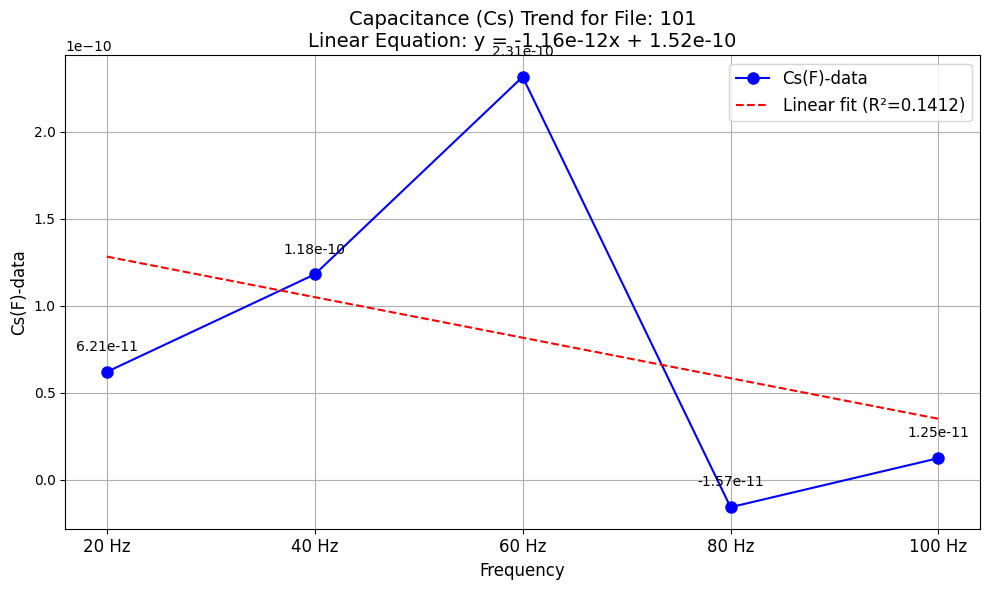

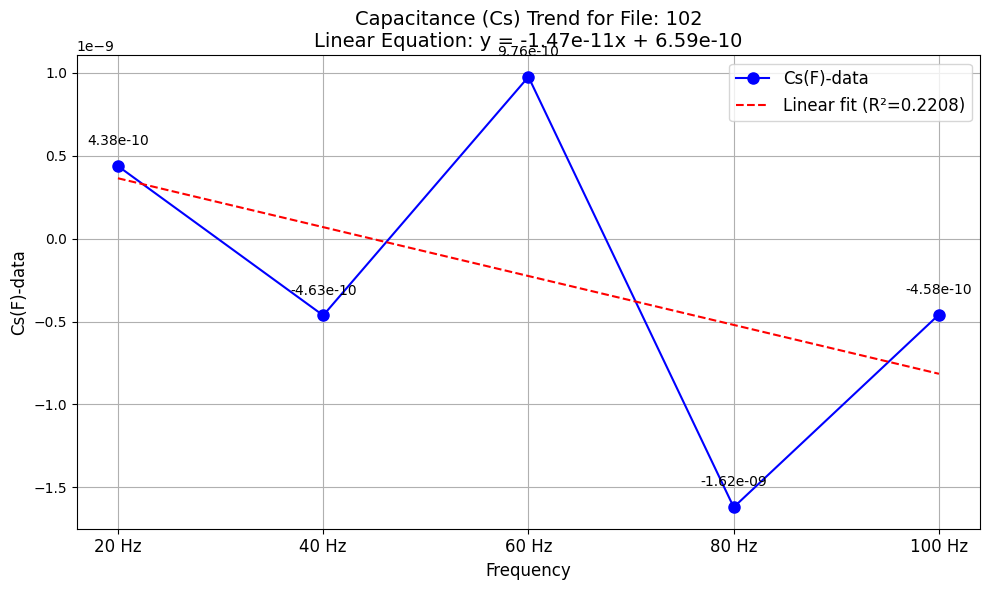

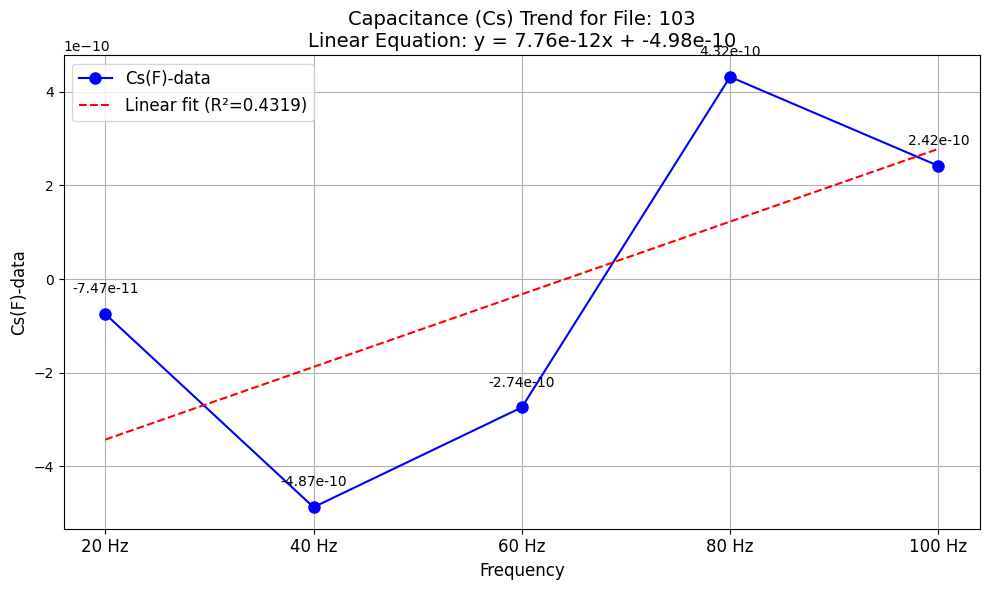

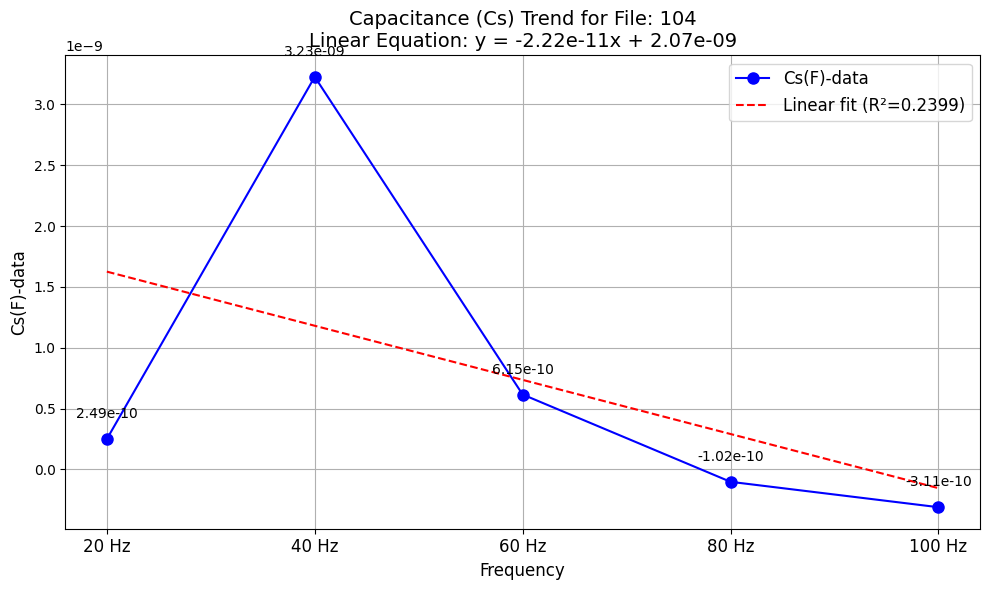

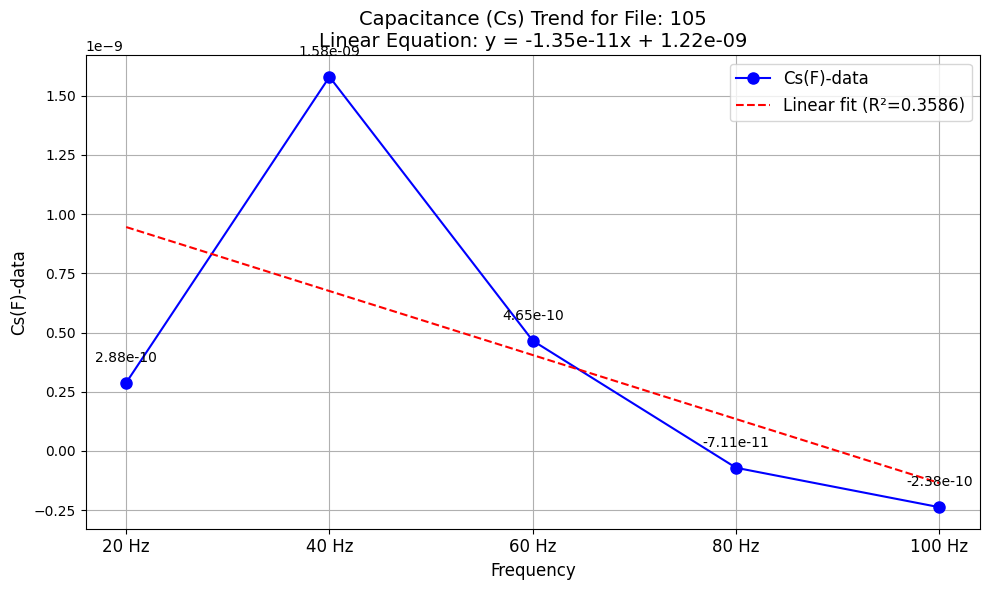

In [7]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from io import StringIO

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # กรองเอาเฉพาะไฟล์ 101.CSV ถึง 105.CSV
    target_files = ['101.csv', '102.csv', '103.csv', '104.csv', '105.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ดึงข้อมูลมาเป็น Text ก่อน เพื่อจัดการกับ Header ของเครื่องวัดที่ติดมา
            raw_text = session.get(url, headers=headers).text
            lines = raw_text.split('\n')
            
            # หาบรรทัดที่เริ่มเก็บข้อมูลจริงๆ (คำว่า Frequency)
            start_idx = 0
            for i, line in enumerate(lines):
                if line.startswith('Frequency'):
                    start_idx = i
                    break
                    
            # นำเข้า Pandas
            csv_data = StringIO('\n'.join(lines[start_idx:]))
            df = pd.read_csv(csv_data)
            df.columns = [c.strip() for c in df.columns] # ลบช่องว่างในชื่อคอลัมน์
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # บันทึกลง Dictionary โดยให้ชื่อไฟล์เป็นตัวพิมพ์ใหญ่
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. เรียกใช้งานฟังก์ชันดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")  # ถ้าไม่ได้ตั้งค่าไว้ในระบบ ค่าจะเป็น None ซึ่งรันได้ปกติ (ถ้าไม่ติด Rate Limit)
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset/01"  # พาธที่เก็บไฟล์ 101-105

# โหลดข้อมูลมาไว้ในตัวแปร dataframes (เป็น Dictionary)
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. วาดกราฟทีละไฟล์
# ==========================================
frequencies = [20.0, 40.0, 60.0, 80.0, 100.0]

# วนลูปวาดกราฟตามจำนวนไฟล์ที่โหลดมาได้
for f_name, df in dataframes.items():
    freqs_found = []
    cs_vals = []
    
    # ดึงค่าตามความถี่ที่ตั้งไว้
    for freq in frequencies:
        row = df[np.isclose(df['Frequency(Hz)'], freq)]
        if not row.empty:
            freqs_found.append(freq)
            cs_vals.append(row['Cs(F)-data'].values[0])
            
    if not freqs_found:
        print(f"⚠️ ไม่พบข้อมูลความถี่ที่ต้องการในไฟล์ {f_name}")
        continue
        
    x = np.array(freqs_found)
    y = np.array(cs_vals)
    
    plt.figure(figsize=(10, 6))
    
    # พล็อตจุดข้อมูล Cs
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # คำนวณ Linear Regression สำหรับหาเทรนด์ Linearity
    valid_idx = ~np.isnan(y)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend for File: {f_name.replace(".CSV","")}\nLinear Equation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend for File: {f_name.replace(".CSV","")}'
    
    # ใส่ Label ตัวเลขที่แต่ละจุดบนกราฟ
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # ตกแต่งกราฟ
    plt.title(title_text, fontsize=14)
    plt.xticks(frequencies, [f"{int(freq)} Hz" for freq in frequencies], fontsize=12)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # สั่งแสดงกราฟขึ้นมา
    plt.show()

กำลังเชื่อมต่อ GitHub: https://api.github.com/repos/NuchPunnawichP/Senior_Project_CU/contents/FirstDataset/01?ref=main
กำลังดาวน์โหลดและอ่านไฟล์: 201.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 202.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 203.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 204.CSV ...
กำลังดาวน์โหลดและอ่านไฟล์: 205.CSV ...

✅ ดึงไฟล์สำเร็จ 5 ไฟล์: ['201.CSV', '202.CSV', '203.CSV', '204.CSV', '205.CSV']



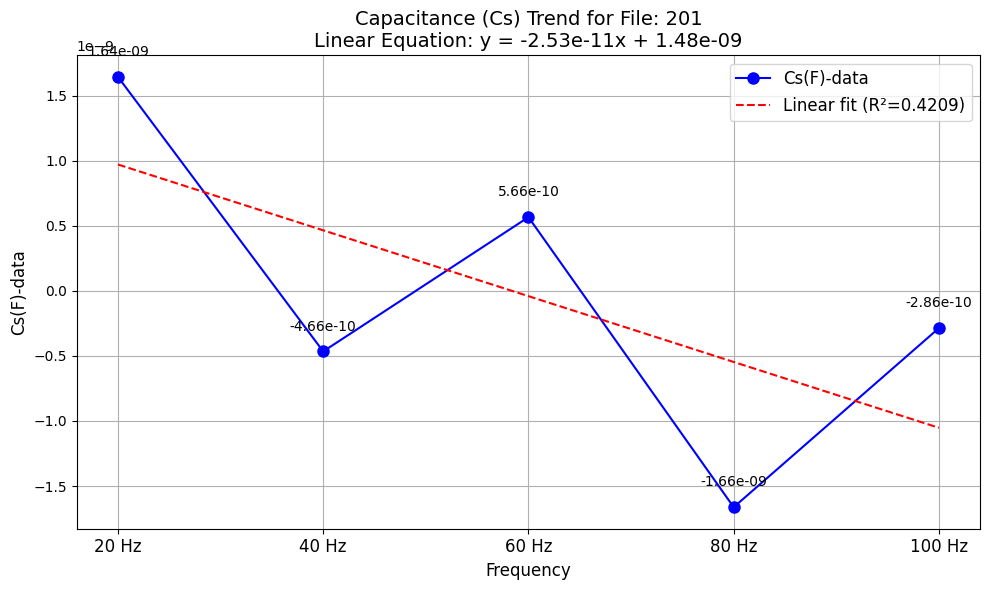

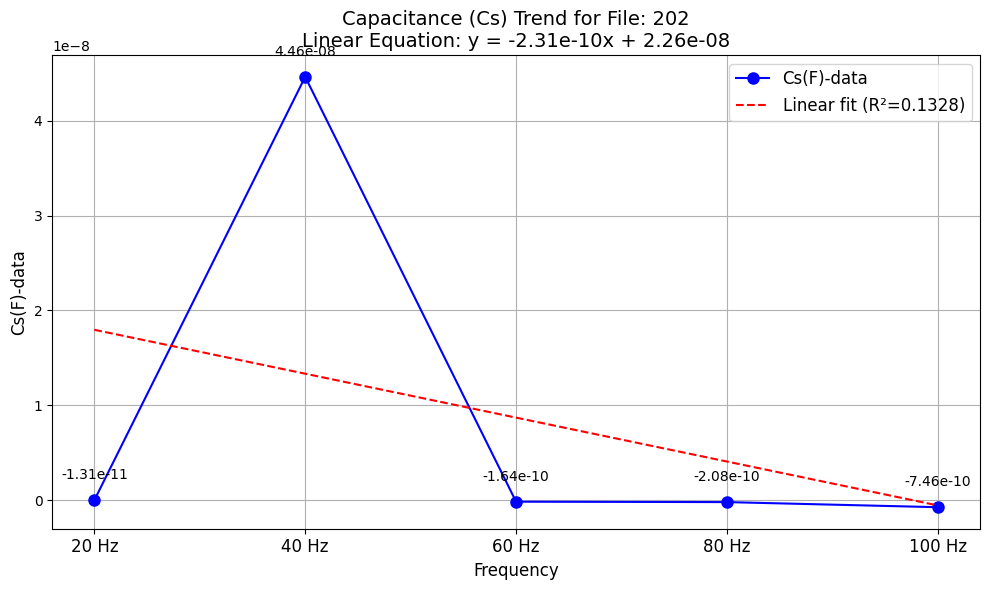

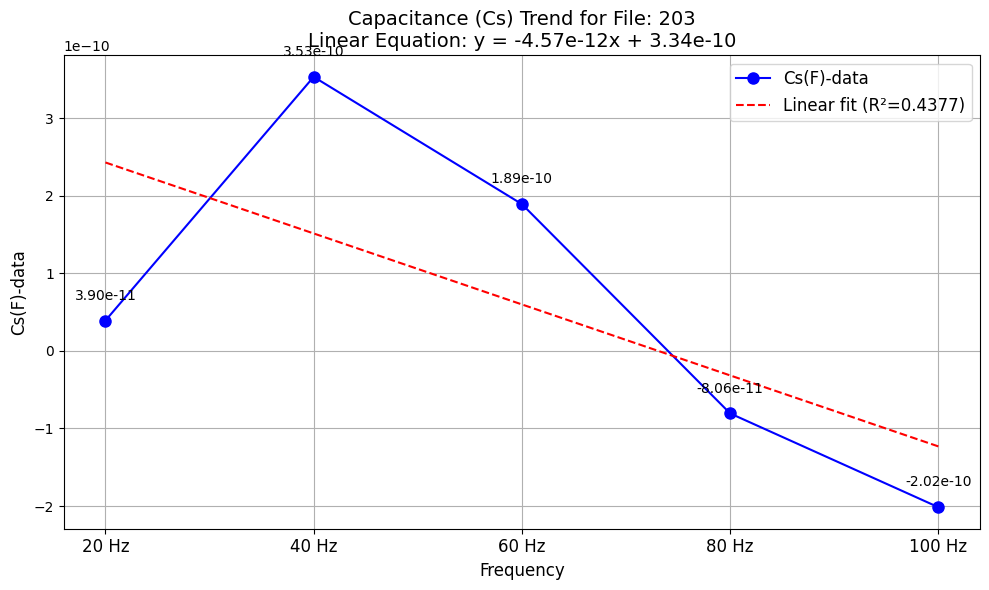

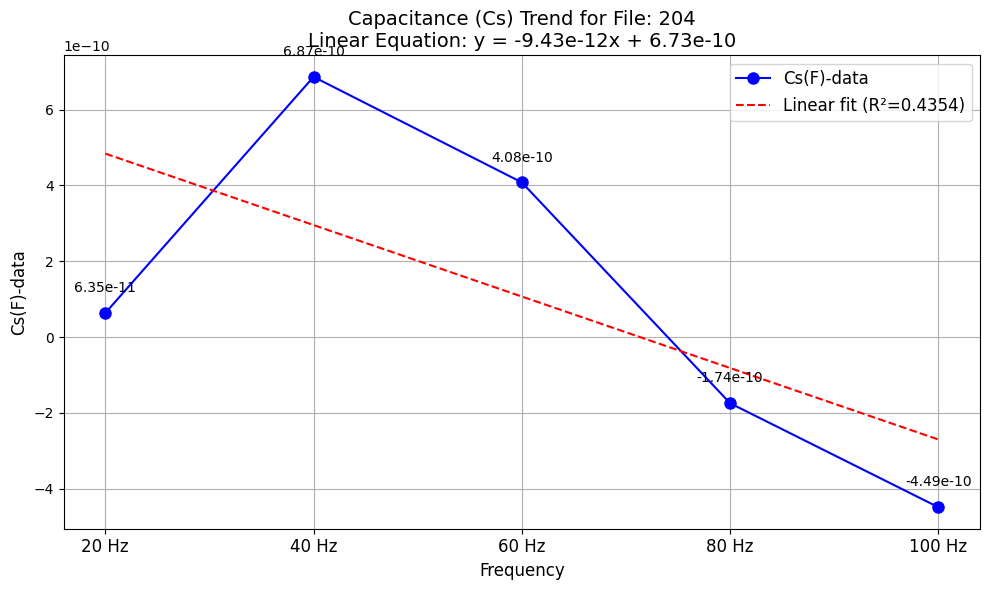

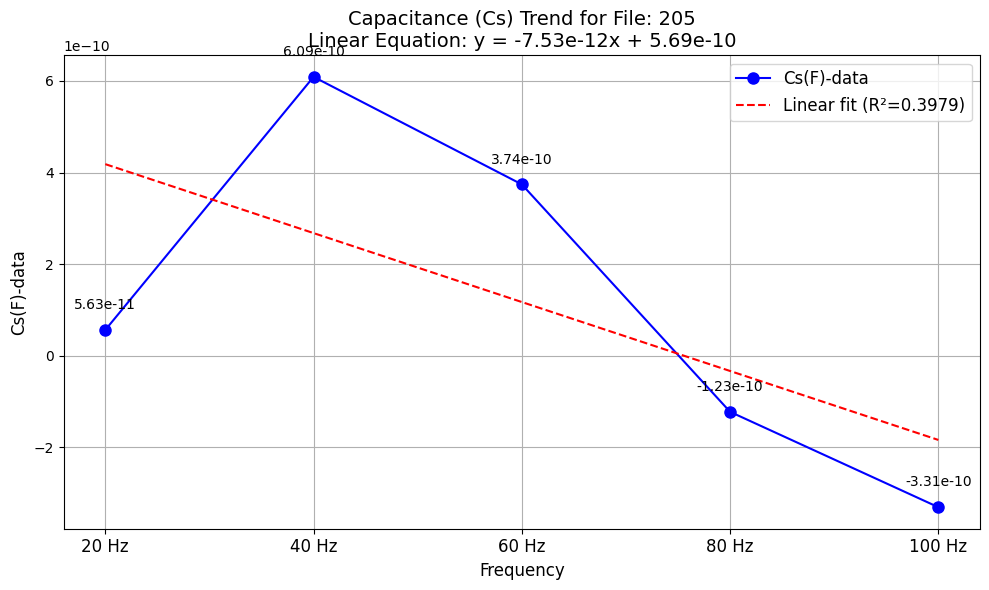

In [8]:
import os
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from io import StringIO

# ==========================================
# 1. ฟังก์ชันโหลดไฟล์จาก GitHub
# ==========================================
def load_csvs_from_github(owner, repo, path, ref="main", token=None):
    session = requests.Session()
    headers = {}
    if token:
        headers["Authorization"] = f"token {token}"
        
    api_url = f"https://api.github.com/repos/{owner}/{repo}/contents/{path}?ref={ref}"
    print(f"กำลังเชื่อมต่อ GitHub: {api_url}")
    
    resp = session.get(api_url, headers=headers)
    resp.raise_for_status()
    items = resp.json()
    
    # กรองเอาเฉพาะไฟล์ 201.CSV ถึง 205.CSV
    target_files = ['201.csv', '202.csv', '203.csv', '204.csv', '205.csv']
    csv_items = [it for it in items if it.get("type") == "file" and it.get("name", "").lower() in target_files]
    
    dfs = {}
    for it in csv_items:
        url = it.get("download_url") or f"https://raw.githubusercontent.com/{owner}/{repo}/{ref}/{path}/{it['name']}"
        print(f"กำลังดาวน์โหลดและอ่านไฟล์: {it['name']} ...")
        try:
            # ดึงข้อมูลมาเป็น Text ก่อน เพื่อจัดการกับ Header ของเครื่องวัดที่ติดมา
            raw_text = session.get(url, headers=headers).text
            lines = raw_text.split('\n')
            
            # หาบรรทัดที่เริ่มเก็บข้อมูลจริงๆ (คำว่า Frequency)
            start_idx = 0
            for i, line in enumerate(lines):
                if line.startswith('Frequency'):
                    start_idx = i
                    break
                    
            # นำเข้า Pandas
            csv_data = StringIO('\n'.join(lines[start_idx:]))
            df = pd.read_csv(csv_data)
            df.columns = [c.strip() for c in df.columns] # ลบช่องว่างในชื่อคอลัมน์
            df['Frequency(Hz)'] = pd.to_numeric(df['Frequency(Hz)'], errors='coerce')
            
            # บันทึกลง Dictionary โดยให้ชื่อไฟล์เป็นตัวพิมพ์ใหญ่
            dfs[it["name"].upper()] = df
        except Exception as e:
            print(f"❌ Failed to read {it['name']}: {e}")
            
    return dfs

# ==========================================
# 2. เรียกใช้งานฟังก์ชันดึงข้อมูล
# ==========================================
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")  # ถ้าไม่ได้ตั้งค่าไว้ในระบบ ค่าจะเป็น None ซึ่งรันได้ปกติ (ถ้าไม่ติด Rate Limit)
owner = "NuchPunnawichP"
repo = "Senior_Project_CU"
path = "FirstDataset/01"  # พาธที่เก็บไฟล์ 201-205

# โหลดข้อมูลมาไว้ในตัวแปร dataframes (เป็น Dictionary)
dataframes = load_csvs_from_github(owner, repo, path, ref="main", token=GITHUB_TOKEN)
print(f"\n✅ ดึงไฟล์สำเร็จ {len(dataframes)} ไฟล์: {list(dataframes.keys())}\n")

# ==========================================
# 3. วาดกราฟทีละไฟล์
# ==========================================
frequencies = [20.0, 40.0, 60.0, 80.0, 100.0]

# วนลูปวาดกราฟตามจำนวนไฟล์ที่โหลดมาได้
for f_name, df in dataframes.items():
    freqs_found = []
    cs_vals = []
    
    # ดึงค่าตามความถี่ที่ตั้งไว้
    for freq in frequencies:
        row = df[np.isclose(df['Frequency(Hz)'], freq)]
        if not row.empty:
            freqs_found.append(freq)
            cs_vals.append(row['Cs(F)-data'].values[0])
            
    if not freqs_found:
        print(f"⚠️ ไม่พบข้อมูลความถี่ที่ต้องการในไฟล์ {f_name}")
        continue
        
    x = np.array(freqs_found)
    y = np.array(cs_vals)
    
    plt.figure(figsize=(10, 6))
    
    # พล็อตจุดข้อมูล Cs
    plt.plot(x, y, 'bo-', label='Cs(F)-data', markersize=8)
    
    # คำนวณ Linear Regression สำหรับหาเทรนด์ Linearity
    valid_idx = ~np.isnan(y)
    if np.sum(valid_idx) > 1:
        slope, intercept, r_value, _, _ = linregress(x[valid_idx], y[valid_idx])
        plt.plot(x, slope * x + intercept, 'r--', label=f'Linear fit (R²={r_value**2:.4f})')
        title_text = f'Capacitance (Cs) Trend for File: {f_name.replace(".CSV","")}\nLinear Equation: y = {slope:.2e}x + {intercept:.2e}'
    else:
        title_text = f'Capacitance (Cs) Trend for File: {f_name.replace(".CSV","")}'
    
    # ใส่ Label ตัวเลขที่แต่ละจุดบนกราฟ
    for i, val in enumerate(y):
        if not np.isnan(val):
            plt.annotate(f'{val:.2e}', 
                         (x[i], val),
                         textcoords="offset points", 
                         xytext=(0, 15), 
                         ha='center', fontsize=10)

    # ตกแต่งกราฟ
    plt.title(title_text, fontsize=14)
    plt.xticks(frequencies, [f"{int(freq)} Hz" for freq in frequencies], fontsize=12)
    plt.xlabel('Frequency', fontsize=12)
    plt.ylabel('Cs(F)-data', fontsize=12)
    
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.tight_layout()
    
    # สั่งแสดงกราฟขึ้นมา
    plt.show()